<a href="https://colab.research.google.com/github/purnasaikrishna06-create/CODSOFT_TASKSNO/blob/main/task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/(cleaned dataset task-1)Employee_Performance_cleaned.csv')

In [19]:
df.head()

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
1,2,Timothy Sanchez,25,Other,Sales,4249,2020-11-09,2.0,11,Inactive,Los Angeles,Evening
2,3,Chad Nichols,57,Other,Sales,3058,2019-02-12,2.0,1,Inactive,New York,Morning
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
4,5,Amber Harris,35,Other,IT,4317,2020-02-15,5.0,16,Inactive,New York,Evening


In [20]:
df.dtypes

,0
ID,int64
Name,object
Age,int64
Gender,object
Department,object
Salary,int64
Joining Date,object
Performance Score,float64
Experience,int64
Status,object


In [21]:
df.describe()


,ID,Age,Salary,Performance Score,Experience
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.782000,5917.374000,2.902000,10.120000
std,288.819436,14.124871,2299.418003,1.381414,5.713689
min,1.000000,18.000000,2015.000000,1.000000,1.000000
25%,250.750000,28.000000,3829.750000,2.000000,5.000000
50%,500.500000,40.000000,5889.000000,3.000000,10.000000
75%,750.250000,52.000000,7903.250000,4.000000,15.000000
max,1000.000000,65.000000,9993.000000,5.000000,20.000000


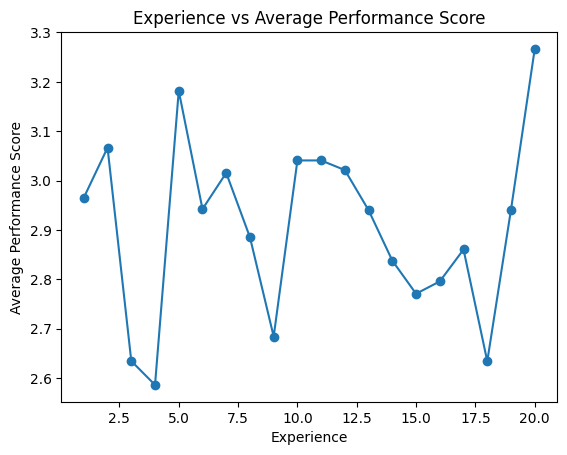

In [22]:
trend=df.groupby("Experience")["Performance Score"].mean().sort_index()
plt.plot(trend.index,trend.values,marker="o")
plt.title("Experience vs Average Performance Score")
plt.xlabel("Experience")
plt.ylabel("Average Performance Score")
plt.show()

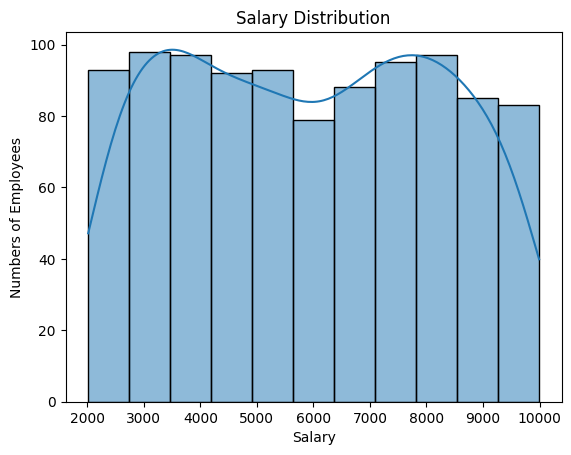

In [23]:
sns.histplot(df["Salary"],kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Numbers of Employees")
plt.show()

Outliers

In [24]:
Q1= df["Salary"].quantile(0.25)
Q3= df["Salary"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers = df[(df["Salary"]<lower_bound) | (df["Salary"]>upper_bound)]
print("number of outliers:",len(outliers))
print(outliers)

number of outliers: 0
Empty DataFrame
Columns: [ID, Name, Age, Gender, Department, Salary, Joining Date, Performance Score, Experience, Status, Location, Session]
Index: []


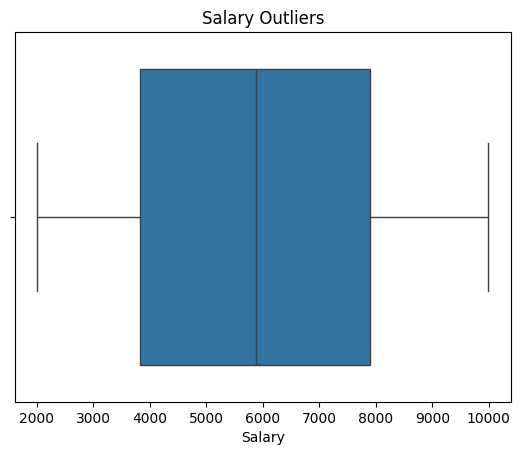

In [25]:
sns.boxplot(x=df["Salary"])
plt.title("Salary Outliers")
plt.xlabel("Salary")
plt.show()

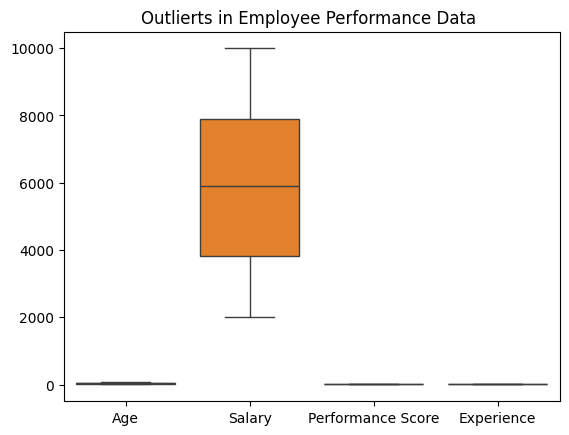

In [26]:
sns.boxplot(data=df[["Age","Salary","Performance Score","Experience"]])
plt.title("Outlierts in Employee Performance Data ")
plt.show()

In [27]:
summary=df[['Age','Salary']].agg(['mean','median','min','max'])
print(summary)
dept_perf=df.groupby('Department')['Performance Score'].agg(['mean','max'])
print(dept_perf)
print(df.groupby('Status')['Performance Score'].agg(['mean','count']))
print(df.groupby('Location')['Salary'].agg(['mean','max']).sort_values('mean',ascending=False).head(1))
print(df['Gender'].value_counts(normalize=True)*100)

           Age    Salary
mean    40.782  5917.374
median  40.000  5889.000
min     18.000  2015.000
max     65.000  9993.000
                mean  max
Department               
HR          2.885449  5.0
IT          2.899705  5.0
Sales       2.920118  5.0
              mean  count
Status                   
Active    2.926148    501
Inactive  2.877756    499
                   mean   max
Location                     
Los Angeles  6006.18209  9963
Gender
Other     34.0
Female    33.2
Male      32.8
Name: proportion, dtype: float64


#Report:
##Overview:
The dataset covers employees across "the HR,IT,and Sales departments",with details on age,salary,experience,performance scores,status and location.The analysis highlights are workforce demographics,compensation and performance trends.
####Employee profile:
- Average age: 40 years
- Average salary: ~6000
####Departement Performance:
- Performance scores are nearly flat across departments — Sales leads slightly , followed by IT  and HR. The gap is small enough that no department meaningfully outperforms the others.
####Employement status:
- Active  employees perform better than inactive employees
####Location Insights:
- Here, Los Angeles employees earn the highest average salaries as compared to other locations
####Gender Distribution:
- Females: 34%
- Males: 33%
- others: 33%
####Business Implications:
- Sales, IT, and HR show comparably strong performance, with no department clearly lagging.
- Salary alignment should be reviewed, especially in Los Angeles.
- Workforce shows balanced gender diversity across categories.

In [28]:
from google.colab import files
files.download("(cleaned dataset task-1)Employee_Performance_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>